# MiniEDA

Importamos las librerías adecuadas para poder realizar el apartado del MiniEDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #data visualization

Cargamos los datos en un DataFrame y lo iremos analizando:

In [2]:
df = pd.read_csv("../data_sample/autoscout24-germany-dataset.csv")


In [3]:
df.head()

,mileage,make,model,fuel,gear,offerType,price,hp,year
0,235000,BMW,316,Diesel,Manual,Used,6800,116.0,2011
1,92800,Volkswagen,Golf,Gasoline,Manual,Used,6877,122.0,2011
2,149300,SEAT,Exeo,Gasoline,Manual,Used,6900,160.0,2011
3,96200,Renault,Megane,Gasoline,Manual,Used,6950,110.0,2011
4,156000,Peugeot,308,Gasoline,Manual,Used,6950,156.0,2011


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46405 entries, 0 to 46404
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mileage    46405 non-null  int64  
 1   make       46405 non-null  object 
 2   model      46262 non-null  object 
 3   fuel       46405 non-null  object 
 4   gear       46223 non-null  object 
 5   offerType  46405 non-null  object 
 6   price      46405 non-null  int64  
 7   hp         46376 non-null  float64
 8   year       46405 non-null  int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 3.2+ MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mileage,46405.0,71177.864109,62625.308456,0.0,19800.0,60000.0,105000.0,1111111.0
price,46405.0,16572.337227,19304.695924,1100.0,7490.0,10999.0,19490.0,1199900.0
hp,46376.0,132.990987,75.449284,1.0,86.0,116.0,150.0,850.0
year,46405.0,2016.012951,3.155214,2011.0,2013.0,2016.0,2019.0,2021.0


In [6]:
df.isnull().sum()

mileage        0
make           0
model        143
fuel           0
gear         182
offerType      0
price          0
hp            29
year           0
dtype: int64

--- 

### Limpieza estructural del dataset

In [7]:
#Limpiamos los nulos:
df_sinNulos = df.dropna()

In [8]:
df_sinNulos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46071 entries, 0 to 46404
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mileage    46071 non-null  int64  
 1   make       46071 non-null  object 
 2   model      46071 non-null  object 
 3   fuel       46071 non-null  object 
 4   gear       46071 non-null  object 
 5   offerType  46071 non-null  object 
 6   price      46071 non-null  int64  
 7   hp         46071 non-null  float64
 8   year       46071 non-null  int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 3.5+ MB


In [9]:
#Nos deshacemos de los posibles duplicados, ya que es habitual encontrar anuncios repetidos en portales de coches.
df_Limpio = df_sinNulos.drop_duplicates()

In [10]:
df_Limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43947 entries, 0 to 46399
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mileage    43947 non-null  int64  
 1   make       43947 non-null  object 
 2   model      43947 non-null  object 
 3   fuel       43947 non-null  object 
 4   gear       43947 non-null  object 
 5   offerType  43947 non-null  object 
 6   price      43947 non-null  int64  
 7   hp         43947 non-null  float64
 8   year       43947 non-null  int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 3.4+ MB


In [11]:
#Una vez hecha la limpieza de datos. Corregiremos los nombres de las columnas para que sean más fáciles de manejar.
df_coches = df_Limpio.rename(
    columns={
    "make": "marca",
    "model": "modelo",
    "year": "año",
    "mileage": "kilometraje (km)",
    "price": "precio (EUR)",
    "fuel": "combustible",
    "gear": "transmisión",
    "offerType": "tipo de oferta",
    "hp": "caballos de fuerza (CV)"
    })

---

### Análisis visual

In [12]:
# Configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 8)

In [13]:
import matplotlib.ticker as ticker

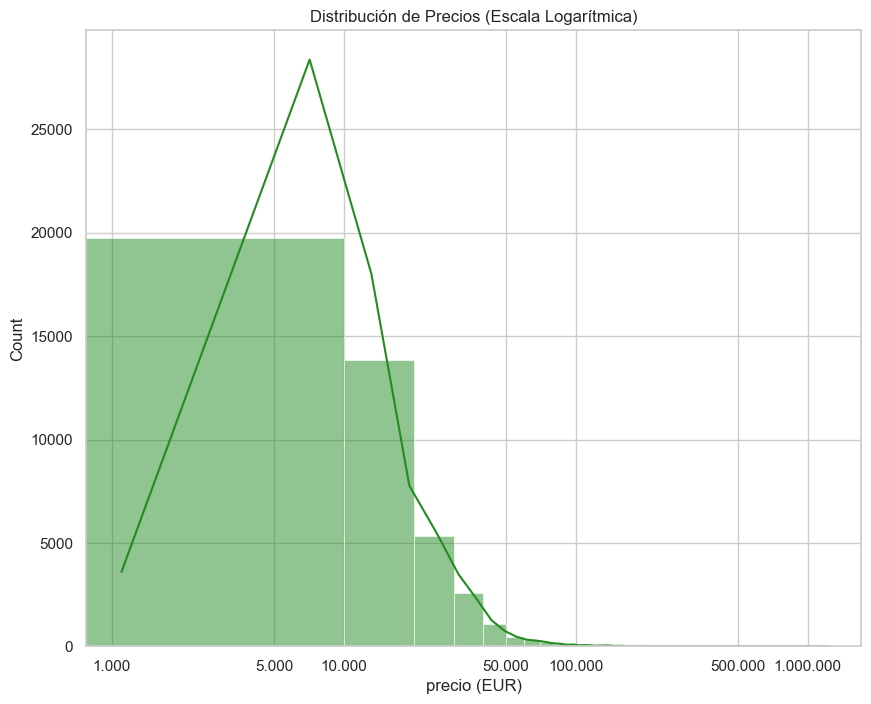

In [14]:
# 1. Distribución del precio

bins = np.arange(0, 1200000, 10000)
ax = sns.histplot(
    df_coches['precio (EUR)'], 
    bins = bins,
    kde=True, 
    color='forestgreen')
plt.xscale("log")

ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', '.')))

plt.xticks([1000, 5000, 10000, 50000, 100000, 500000, 1000000])

plt.title('Distribución de Precios (Escala Logarítmica)')
plt.show()

La gran mayoría de los anuncios se concentran en el rango de 10.000 € a 30.000 €. Presenta una fuerte asimetría a la derecha, con una "cola" larga de vehículos de alta gama que superan los 100.000 €.

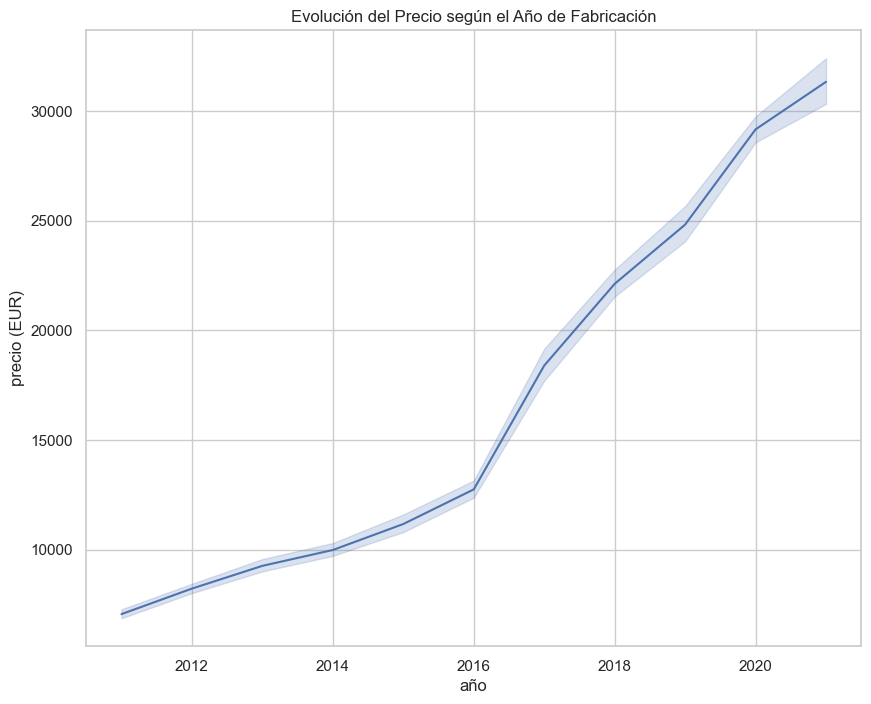

In [15]:
# 2. Relación Año vs Precio

sns.lineplot(
    data=df_coches, 
    x='año', 
    y='precio (EUR)')
plt.title('Evolución del Precio según el Año de Fabricación')
plt.show()

Se confirma una depreciación exponencial. Los vehículos más recientes mantienen valores altos, mientras que a partir de los 10 años de antigüedad el precio tiende a estancarse en valores residuales.
El año es, probablemente, la variable con mayor poder predictivo. La relación no es perfectamente lineal, lo que justifica el uso de algoritmos no lineales.

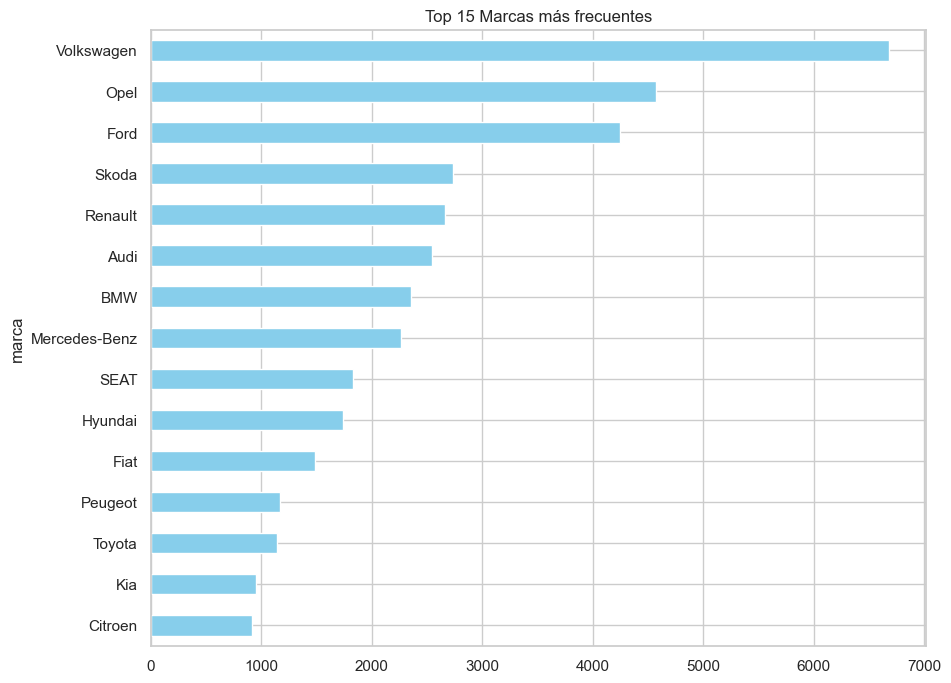

In [16]:
# 3. Top 15 Marcas por frecuencia

df_coches['marca'].value_counts().head(15).plot(kind='barh', color='skyblue')
plt.title('Top 15 Marcas más frecuentes')
plt.gca().invert_yaxis() # Para que la más frecuente salga arriba
plt.show()

El mercado alemán está dominado por marcas locales (Volkswagen, BMW, Mercedes-Benz, Audi, Opel). Estas marcas suponen el grueso del dataset.
Al haber marcas con miles de registros y otras con apenas una decena, deberemos agrupar las menos frecuentes bajo una categoría "Otros" o usar un Encoding inteligente para evitar que el modelo genere ruido con marcas minoritarias.

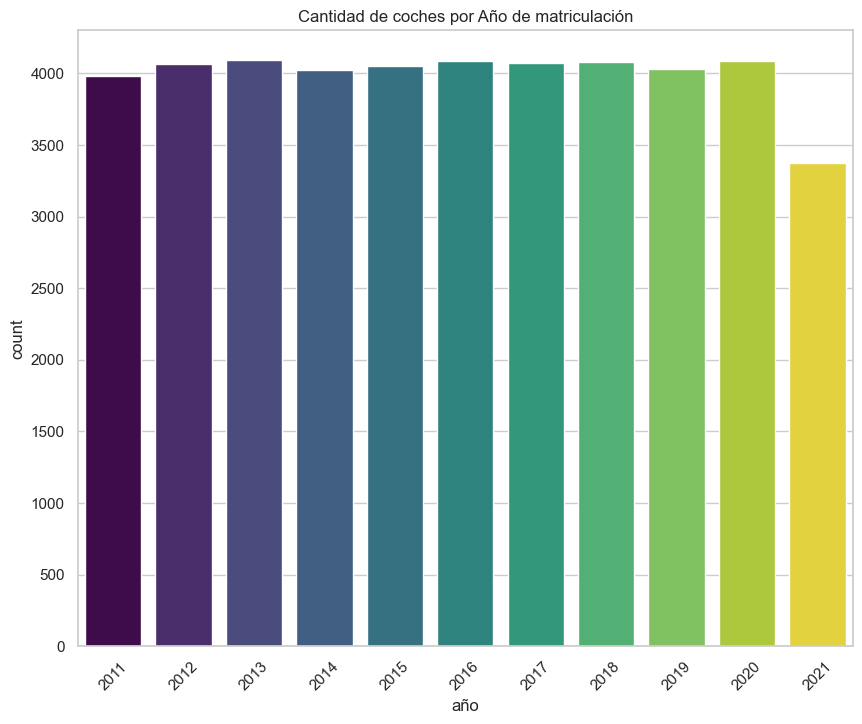

In [17]:
#Distribución de la Antigüedad (Año)

sns.countplot(
    data=df_coches, 
    x='año',
    hue = 'año', 
    palette='viridis',
    legend=False)    
plt.xticks(rotation=45)
plt.title('Cantidad de coches por Año de matriculación')
plt.show()


Existe un volumen masivo de vehículos matriculados entre 2011 y 2019. Hay un ligero descenso en años de pandemia (2020-2021), lo cual refleja fielmente la realidad del mercado de stock.

Text(0.5, 1.0, 'Relación Potencia vs Precio')

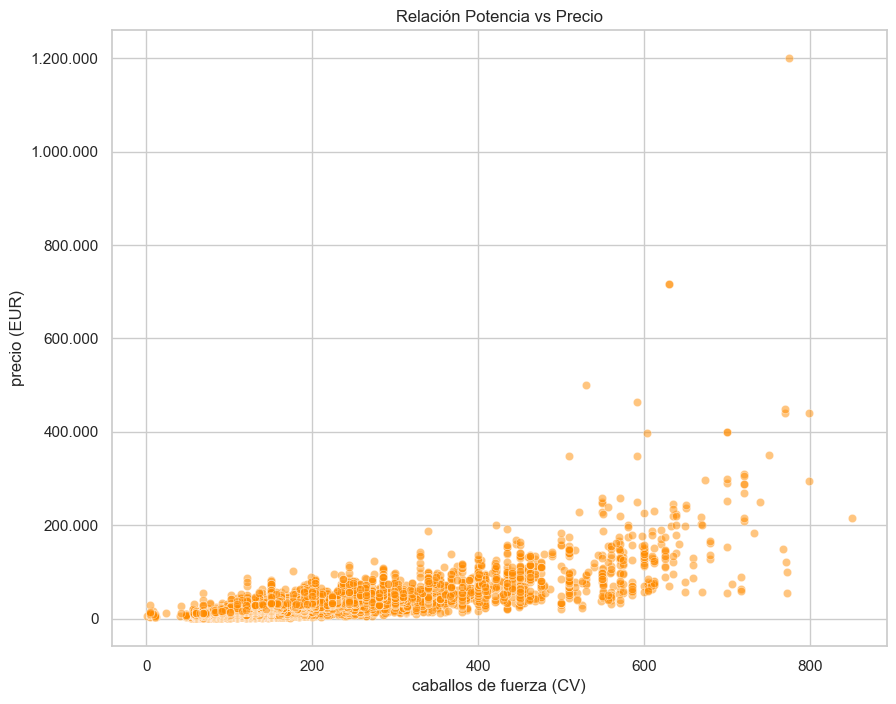

In [18]:
# Relación Caballos vs Precio

ax = sns.scatterplot(
    data=df_coches, 
    x='caballos de fuerza (CV)', 
    y='precio (EUR)', 
    alpha=0.5, 
    color='darkorange'
)

# Quitamos la notación científica (el 1e6)
plt.ticklabel_format(style='plain', axis='y')

# Ponemos los puntos de los miles para que sea legible (ej. 25.000)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', '.')))
plt.title('Relación Potencia vs Precio')

Existe una correlación positiva clara: a mayor potencia (CV), mayor es el precio de venta. Sin embargo, se observa mucha dispersión en potencias altas, donde otros factores (como la marca de lujo) influyen más que los propios caballos.

La potencia será clave. Los puntos aislados en la parte superior derecha (muchos CV y precio altísimo) confirman la presencia de vehículos de nicho/lujo que el modelo deberá aprender a distinguir del mercado generalista.

--- 

# Preprocesado y Feature Engineering

### Tratamiento de valores faltantes

Dada la naturaleza del dataset (un portal de compraventa de prestigio como AutoScout24) y el volumen masivo de datos disponibles (+46.000 registros), se ha optado por la eliminación de filas con valores nulos en lugar de la imputación. Esto garantiza que el modelo aprenda de datos reales y precisos, evitando introducir ruido o sesgos mediante medias o medianas en variables críticas como el precio o la potencia

---

### Gestión de valores duplicados

Se han eliminado los registros duplicados para evitar el sobreajuste (overfitting). Mantener anuncios idénticos sesgaría al modelo dándole más peso a vehículos que simplemente han sido publicados varias veces por el mismo concesionario

---

### Creación de nuevas features (Feature Engineering)


In [19]:
# 1. Antigüedad del coche (asumiendo que estamos analizando el dataset a fecha de hoy)
df_coches['antigüedad'] = 2026 - df_coches['año']

# 2. Kilómetros anuales (ojo: sumamos 1 al divisor para evitar divisiones por cero en coches nuevos)
df_coches['km_anuales'] = df_coches['kilometraje (km)'] / (df_coches['antigüedad'] + 1)

In [20]:
# 3. ¿Es marca de lujo? 

# 1. Calculamos la mediana de precio para cada marca
precios_medios_marca = df_coches.groupby('marca')['precio (EUR)'].median()

# 2. Definimos los puntos de corte (Percentiles)
p25 = precios_medios_marca.quantile(0.25) # Límite Económico
p75 = precios_medios_marca.quantile(0.75) # Límite Media-Alta
p90 = precios_medios_marca.quantile(0.90) # Límite Lujo

# 3. Función para asignar la gama
def asignar_gama(marca):
    precio = precios_medios_marca[marca]
    if precio <= p25:
        return 0  # Gama Económica (Dacia, Fiat...)
    elif precio <= p75:
        return 1  # Gama Media (Seat, Opel, Renault...)
    elif precio <= p90:
        return 2  # Gama Alta (BMW, Audi, Mercedes...)
    else:
        return 3  # Gama Lujo (Ferrari, Rolls-Royce...)

# 4. Creamos la nueva columna
df_coches['gama_marca'] = df_coches['marca'].apply(asignar_gama)

In [21]:
# Creamos un diccionario para ver ejemplos de cada gama
ejemplos_gamas = {}

for nivel in range(4):
    nombres_gama = {0: "Económica", 1: "Media", 2: "Alta", 3: "Lujo"}
    # Sacamos 5 marcas aleatorias de cada categoría para el ejemplo
    marcas_en_gama = df_coches[df_coches['gama_marca'] == nivel]['marca'].unique()[:5]
    ejemplos_gamas[nombres_gama[nivel]] = list(marcas_en_gama)

# Mostramos los ejemplos de forma limpia
print("EJEMPLOS DE CLASIFICACIÓN POR GAMAS:")
print("-" * 40)
for gama, marcas in ejemplos_gamas.items():
    print(f"{gama}: {', '.join(marcas)}...")

EJEMPLOS DE CLASIFICACIÓN POR GAMAS:
----------------------------------------
Económica: Renault, Peugeot, Opel, Chevrolet, Fiat...
Media: BMW, Volkswagen, SEAT, Toyota, Mazda...
Alta: Porsche, Maserati, Land, Tesla, Morgan...
Lujo: Bentley, Lamborghini, McLaren, Aston, Rolls-Royce...


Se ha implementado una ingeniería de variables (Feature Engineering) para capturar el posicionamiento de mercado de cada fabricante. Dado que la columna 'marca' tiene una alta cardinalidad (muchos valores distintos), la creación de gama_marca permite al modelo entender jerarquías de precios.

Económica (Q1): Marcas con una mediana de precio en el 25% inferior.

Media (Q1 a Q3): El grueso del mercado generalista.

Alta (Q3 a P90): Segmento Premium.

Lujo (>P90): Marcas de nicho con precios radicalmente superiores.

Esta discretización ayuda al algoritmo a reducir el error en predicciones de vehículos con características técnicas similares pero marcas con distinto valor de reventa.

In [22]:
df_coches.sample(10)

,kilometraje (km),marca,modelo,combustible,transmisión,tipo de oferta,precio (EUR),caballos de fuerza (CV),año,antigüedad,km_anuales,gama_marca
40240,48750,Volkswagen,Golf Sportsvan,Diesel,Manual,Used,14390,110.0,2016,10,4431.818182,1
43831,24200,Audi,A4,Gasoline,Manual,Used,24990,150.0,2019,7,3025.000000,1
41002,170615,Mercedes-Benz,GLE 350,Diesel,Automatic,Used,32950,258.0,2017,9,17061.500000,1
17449,62442,Ford,Kuga,Diesel,Manual,Used,13750,140.0,2015,11,5203.500000,1
33815,36100,Land,Rover Discovery,Diesel,Automatic,Used,31450,179.0,2018,8,4011.111111,2
11848,50250,Nissan,Qashqai,Gasoline,Automatic,Used,12490,141.0,2013,13,3589.285714,1
22449,87000,Audi,Q3,Diesel,Automatic,Used,17499,177.0,2012,14,5800.000000,1
18728,62000,Volkswagen,Passat Variant,Diesel,Manual,Used,14990,120.0,2015,11,5166.666667,1
4895,69000,Dacia,Lodgy,Gasoline,Manual,Used,6980,83.0,2012,14,4600.000000,0
9038,5,Jeep,Compass,Gasoline,Automatic,Pre-registered,24860,150.0,2020,6,0.714286,1


---

### División del Dataset (Train/Test Split)

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X = df_coches.drop('precio (EUR)', axis=1)
y = df_coches['precio (EUR)']

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Registros para entrenamiento: {len(X_train)}")
print(f"Registros para evaluación: {len(X_test)}")

Registros para entrenamiento: 35157
Registros para evaluación: 8790


### Análisis de la Variable Objetivo (precio (EUR))

Como vimos en el histograma, el precio tiene una asimetría positiva. Se observa que la mayoría de los datos están en el rango 10k-30k

Debido a la gran diferencia entre el precio mínimo y máximo, se evaluará el uso de modelos basados en árboles (Random Forest) que son menos sensibles a esta distribución que la regresión lineal

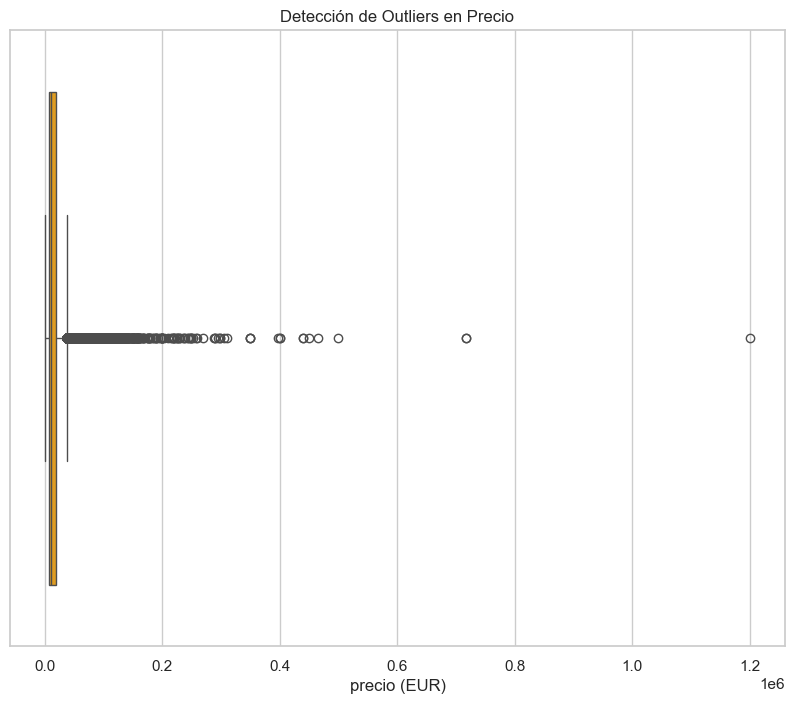

In [25]:
#Detección y tratamiento de Outliers

plt.figure(figsize=(10, 8))
sns.boxplot(x=y, color='orange')
plt.title('Detección de Outliers en Precio')
plt.show()

Se detectan valores atípicos por encima de los 150.000 €. Se decide mantenerlos para que el modelo sea capaz de identificar vehículos de lujo, pero se aplicará un escalado robusto en el preprocesado

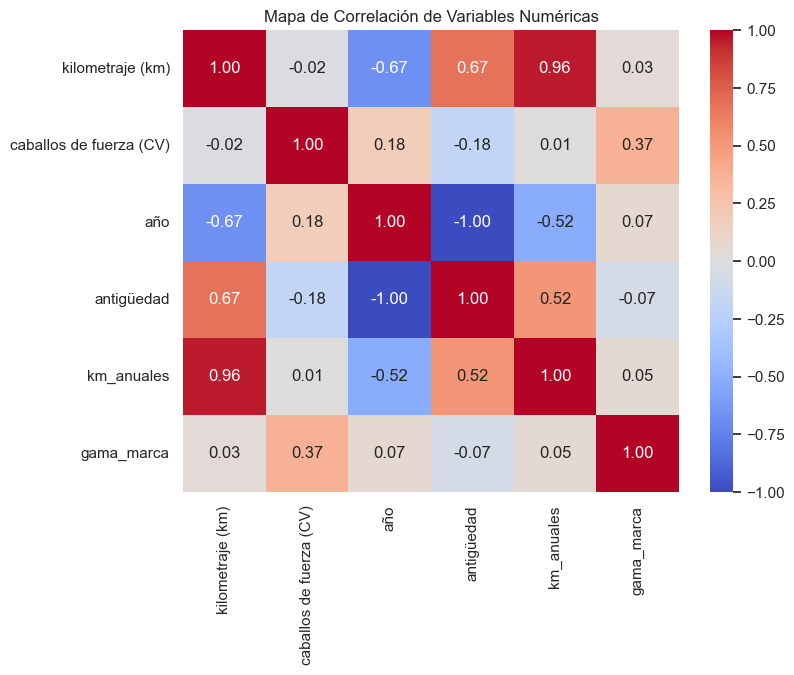

In [26]:
# Análisis de Correlaciones

plt.figure(figsize=(8, 6))
# Solo columnas numéricas del train
sns.heatmap(
    X_train.select_dtypes(include=['number']).corr(), 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f")
plt.title('Mapa de Correlación de Variables Numéricas')
plt.show()

El año y la potencia (CV) presentan la correlación más alta con el precio, confirmando que serán las variables con mayor peso en el modelo

Visualizaciones que justifican el Preprocesado

In [27]:
df_coches['modelo'].nunique()

835

Dado que existen más de 500 modelos distintos, un One-Hot Encoding crearía demasiadas columnas. Se optará por un Target Encoding o Label Encoding.

En cuanto a nuevas variables: La relación entre año y precio justifica la creación de una variable antigüedad para capturar la depreciación de forma más directa